# List 9
## Author: Jan Pułtorak

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("mps" if torch.mps.is_available() else "cpu")

## Task 1

In [2]:
n = 1000

u = torch.randn(n, 1)
v = torch.randn(n, 1)

x1 = u
x2 = 0.5 * u + v
x3 = 2.0 * u - 0.3 * v + 0.1 * torch.randn(n, 1)

X = torch.cat([x1, x2, x3], dim=1)

# Center the data
X = X - X.mean(dim=0, keepdim=True)

In [10]:
class LinearAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Linear(3, 2)
        self.decoder = nn.Linear(2, 3)

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

model = LinearAE()
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.01)

epochs = 500
losses = []

for epoch in range(epochs):
    optimizer.zero_grad()
    x_hat, _ = model(X)
    loss = criterion(x_hat, X)
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

model.eval()
with torch.no_grad():
    X_reconstructed_ae, Z_ae = model(X)
    mse_ae = criterion(X_reconstructed_ae, X).item()

In [11]:
X_np = X.numpy()

pca = PCA(n_components=2)
Z_pca = pca.fit_transform(X_np)
X_reconstructed_pca = pca.inverse_transform(Z_pca)

mse_pca = np.mean((X_np - X_reconstructed_pca) ** 2)

results_df = pd.DataFrame({
    "Method": ["Linear AE", "PCA"],
    "Latent dimension": [2, 2],
    "Reconstruction MSE": [mse_ae, mse_pca]
})

results_df

,Method,Latent dimension,Reconstruction MSE
0,Linear AE,2,0.000648
1,PCA,2,0.000579


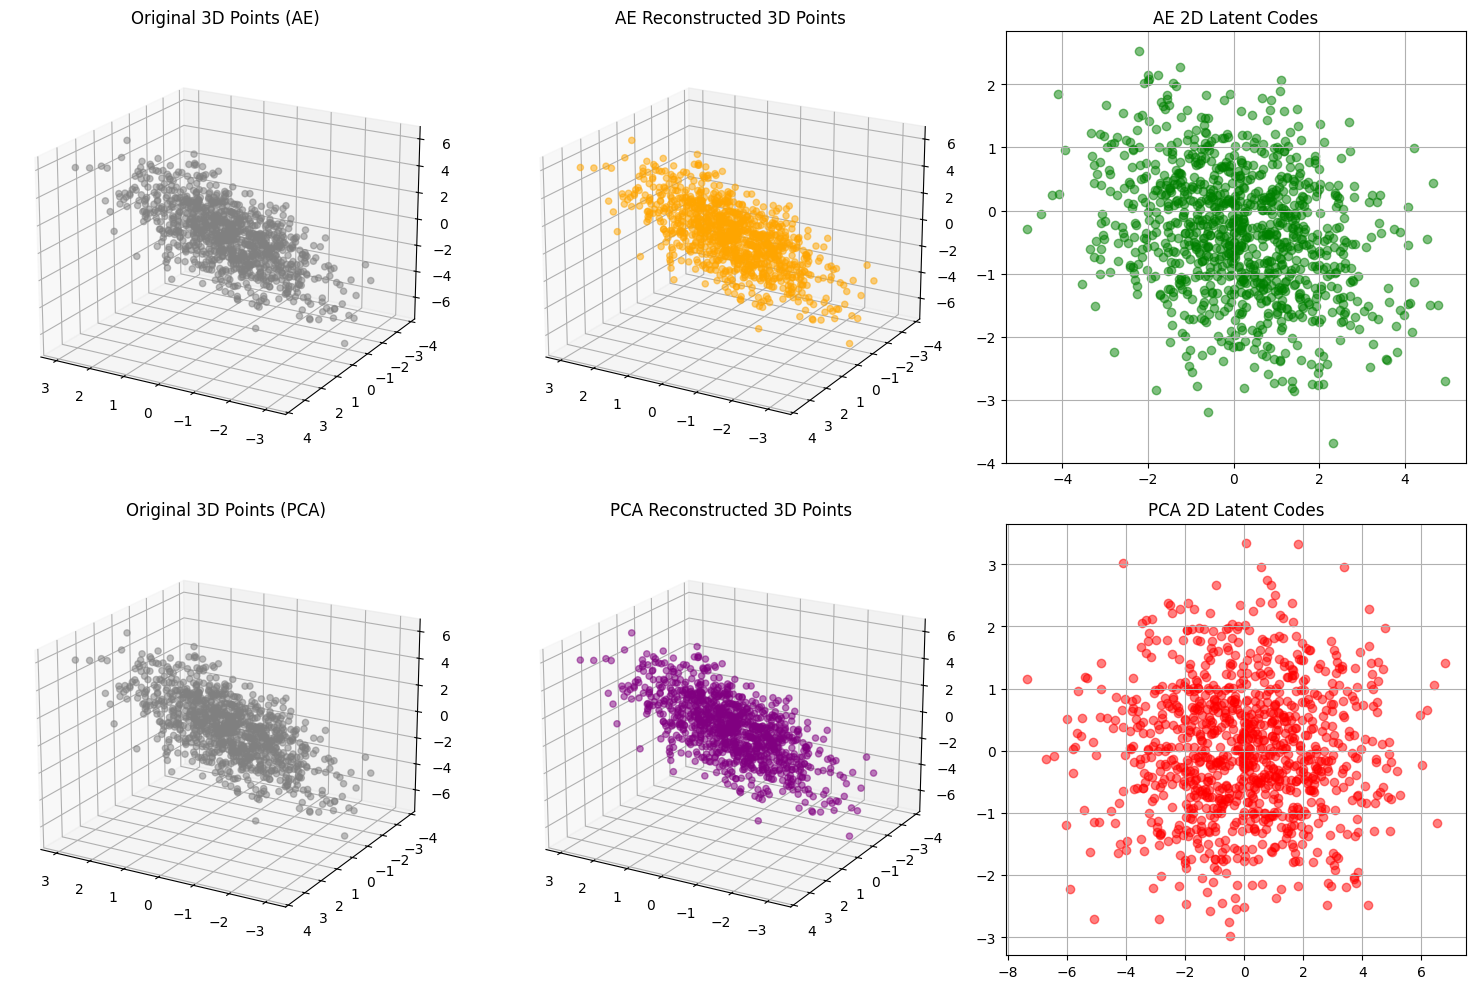

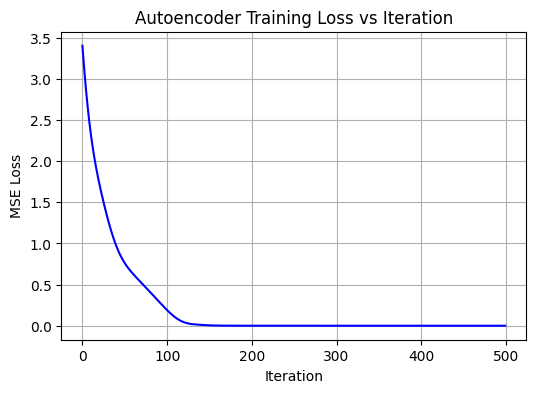

In [14]:
fig = plt.figure(figsize=(15, 10))

# Linear AE
ax1 = fig.add_subplot(2, 3, 1, projection='3d')
ax1.scatter(X_np[:, 0], X_np[:, 1], X_np[:, 2], alpha=0.5, color='gray')
ax1.view_init(elev=20, azim=120)
ax1.set_title("Original 3D Points (AE)")

X_rec_ae_np = X_reconstructed_ae.numpy()
ax2 = fig.add_subplot(2, 3, 2, projection='3d')
ax2.scatter(X_rec_ae_np[:, 0], X_rec_ae_np[:, 1], X_rec_ae_np[:, 2], alpha=0.5, color='orange')
ax2.view_init(elev=20, azim=120)
ax2.set_title("AE Reconstructed 3D Points")

Z_ae_np = Z_ae.numpy()
ax3 = fig.add_subplot(2, 3, 3)
ax3.scatter(Z_ae_np[:, 0], Z_ae_np[:, 1], alpha=0.5, color='green')
ax3.set_title("AE 2D Latent Codes")
ax3.grid(True)

# PCA
ax4 = fig.add_subplot(2, 3, 4, projection='3d')
ax4.scatter(X_np[:, 0], X_np[:, 1], X_np[:, 2], alpha=0.5, color='gray')
ax4.view_init(elev=20, azim=120)
ax4.set_title("Original 3D Points (PCA)")

ax5 = fig.add_subplot(2, 3, 5, projection='3d')
ax5.scatter(X_reconstructed_pca[:, 0], X_reconstructed_pca[:, 1], X_reconstructed_pca[:, 2], alpha=0.5, color='purple')
ax5.view_init(elev=20, azim=120)
ax5.set_title("PCA Reconstructed 3D Points")

ax6 = fig.add_subplot(2, 3, 6)
ax6.scatter(Z_pca[:, 0], Z_pca[:, 1], alpha=0.5, color='red')
ax6.set_title("PCA 2D Latent Codes")
ax6.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(losses, color='blue')
plt.title("Autoencoder Training Loss vs Iteration")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

### Discussion

* **What the encoder learns:** It learns an affine transformation from $R^3$ to $R^2$.
* **What the decoder learns:** It learns an affine transformation from $R^2$ to $R^3$.
* **Why the bottleneck forces compression:** The model must earn to compress 3-dimensional vectors into 2-dimensional ones.
* **Why the result should be similar to PCA:** Both models essentially find a lower, 2-dimensional subspace of the original space, which minimize the MSE.
* **Why the latent coordinates of the autoencoder do not have to be identical to PCA coordinates:** They can differ up to a invertible linear transformation.
* **Whether the autoencoder and PCA reached similar reconstruction errors:** As shown in the table, the MSE values are nearly identical.

## Task 2

In [3]:
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

transform = transforms.ToTensor()

full_train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)


train_size = 50000
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [4]:
def add_noise(x, noise_std=0.3):
    noise = torch.randn_like(x) * noise_std
    x_noisy = x + noise
    x_noisy = torch.clamp(x_noisy, 0.0, 1.0)
    return x_noisy

class ConvDenoisingAE(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder: (B, 1, 28, 28) -> (B, 4, 14, 14) -> (B, 8, 7, 7)
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=4, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=4, out_channels=8, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
        )

        # Decoder: (B, 8, 7, 7) -> (B, 4, 14, 14) -> (B, 1, 28, 28)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(in_channels=8, out_channels=4, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=4, out_channels=1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

In [11]:
def train_one_epoch(model, loader, optimizer, criterion, device, noise_std):
    model.train()
    total_loss = 0.0
    total_samples = 0

    for clean, _ in loader:
        clean = clean.to(device)
        noisy = add_noise(clean, noise_std=noise_std)

        optimizer.zero_grad()
        reconstructed = model(noisy)
        loss = criterion(reconstructed, clean)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * clean.size(0)
        total_samples += clean.size(0)

    return total_loss / total_samples


epochs = 5
noise_levels = [0.1, 0.3, 0.5, 1]
models = {}
loss_histories = {}

for std in noise_levels:
    print(f"Training Denoising AE with noise std = {std}")
    model = ConvDenoisingAE().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()

    losses = []
    for epoch in range(epochs):
        loss = train_one_epoch(model, train_loader, optimizer, criterion, device, noise_std=std)
        losses.append(loss)
        print(f"  Epoch {epoch+1}/{epochs} - Loss: {loss:.4f}")

    models[std] = model
    loss_histories[std] = losses

Training Denoising AE with noise std = 0.1
  Epoch 1/5 - Loss: 0.0298
  Epoch 2/5 - Loss: 0.0125
  Epoch 3/5 - Loss: 0.0113
  Epoch 4/5 - Loss: 0.0108
  Epoch 5/5 - Loss: 0.0106
Training Denoising AE with noise std = 0.3
  Epoch 1/5 - Loss: 0.0272
  Epoch 2/5 - Loss: 0.0149
  Epoch 3/5 - Loss: 0.0140
  Epoch 4/5 - Loss: 0.0134
  Epoch 5/5 - Loss: 0.0132
Training Denoising AE with noise std = 0.5
  Epoch 1/5 - Loss: 0.0352
  Epoch 2/5 - Loss: 0.0237
  Epoch 3/5 - Loss: 0.0227
  Epoch 4/5 - Loss: 0.0224
  Epoch 5/5 - Loss: 0.0223
Training Denoising AE with noise std = 1
  Epoch 1/5 - Loss: 0.0583
  Epoch 2/5 - Loss: 0.0432
  Epoch 3/5 - Loss: 0.0426
  Epoch 4/5 - Loss: 0.0425
  Epoch 5/5 - Loss: 0.0423


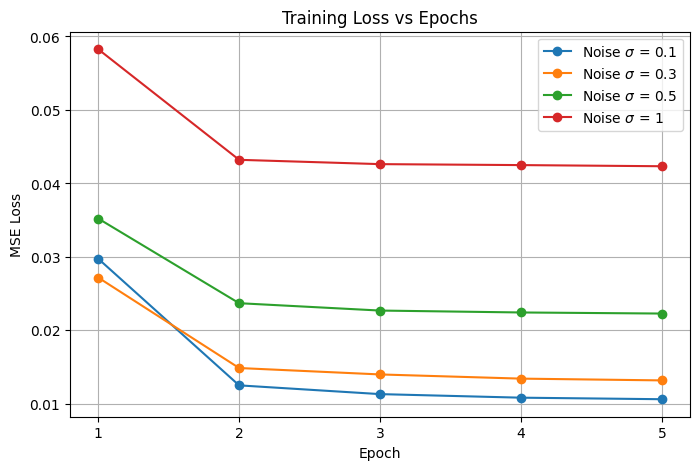

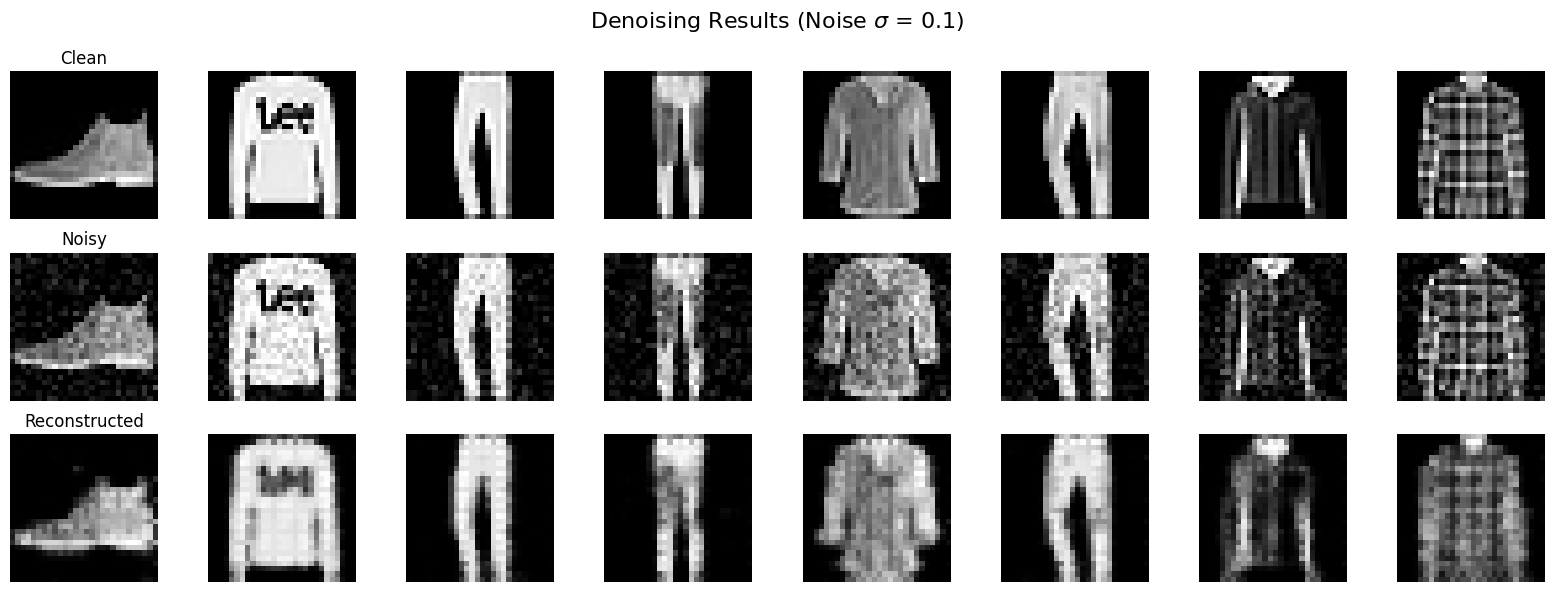

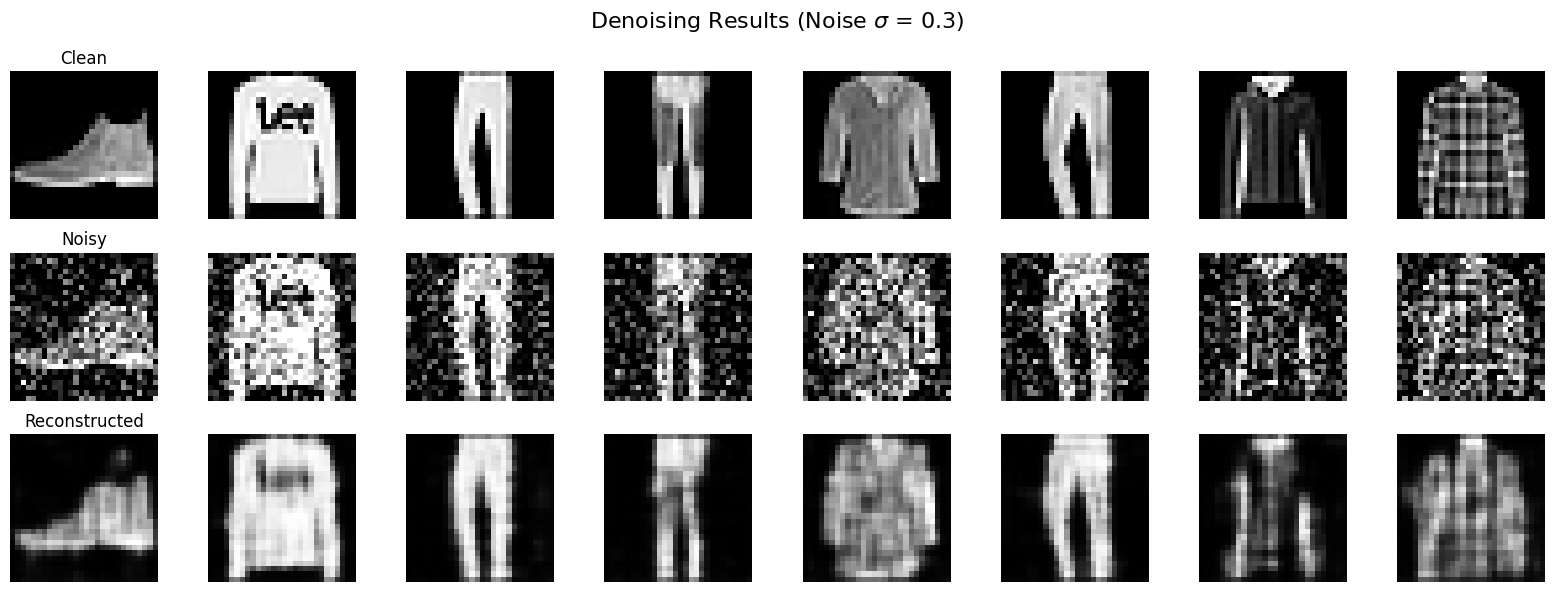

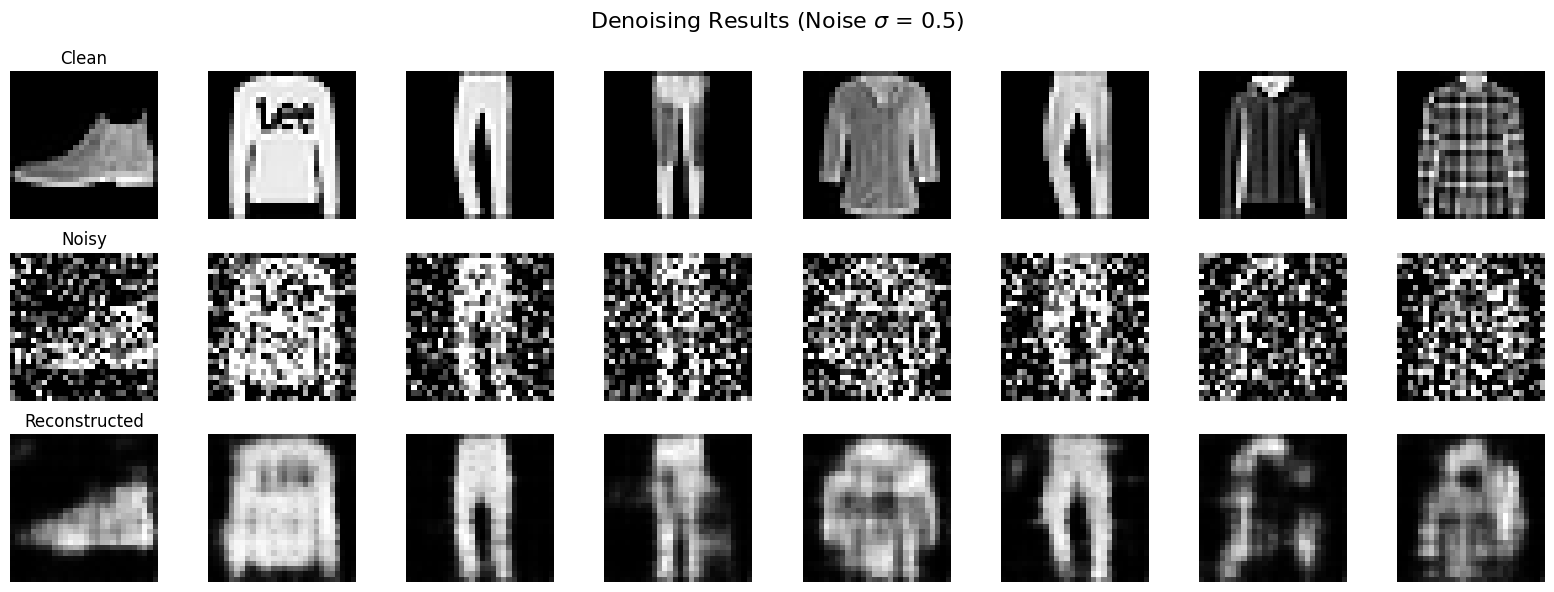

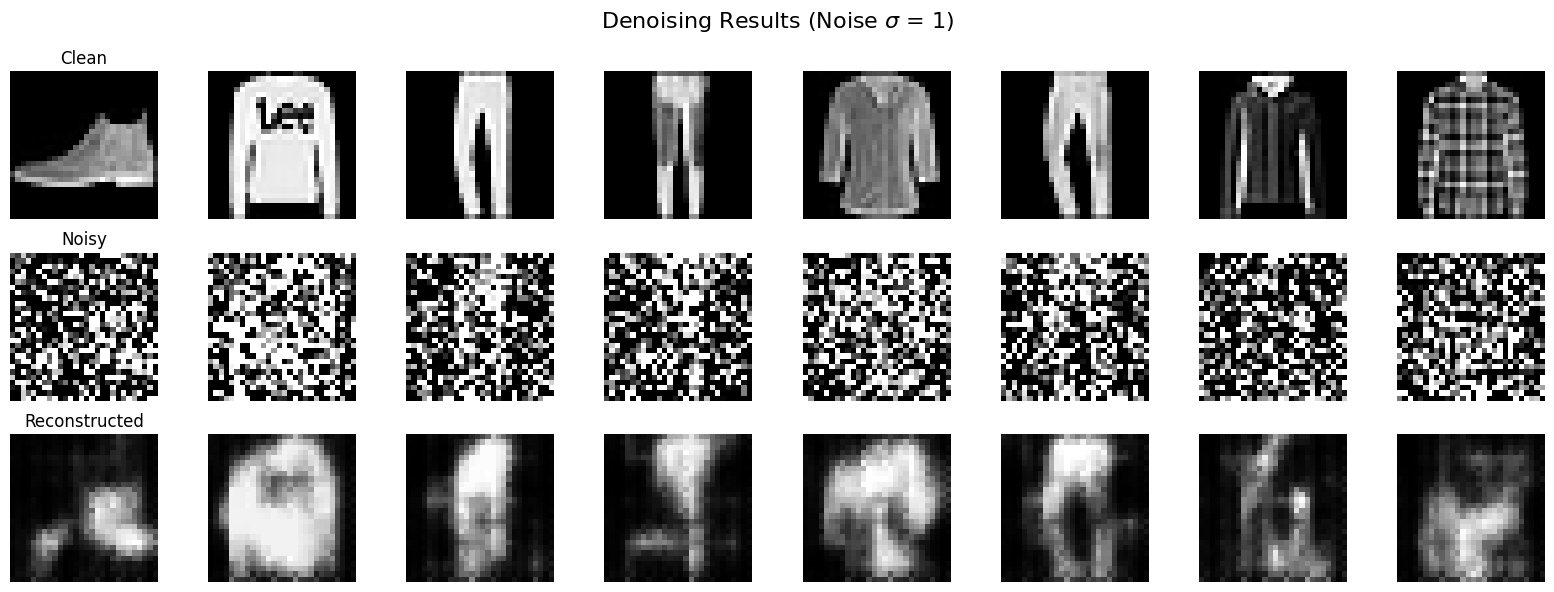

In [12]:
def visualize_denoising(model, loader, device, noise_std, num_examples=8):
    model.eval()

    clean_images, _ = next(iter(loader))
    clean_images = clean_images[:num_examples].to(device)
    noisy_images = add_noise(clean_images, noise_std)

    with torch.no_grad():
        reconstructed = model(noisy_images)

    clean_images = clean_images.cpu().squeeze(1).numpy()
    noisy_images = noisy_images.cpu().squeeze(1).numpy()
    reconstructed = reconstructed.cpu().squeeze(1).numpy()

    fig, axes = plt.subplots(3, num_examples, figsize=(num_examples * 2, 6))
    plt.suptitle(rf"Denoising Results (Noise $\sigma$ = {noise_std})", fontsize=16)

    for i in range(num_examples):
        axes[0, i].imshow(clean_images[i], cmap='gray')
        axes[0, i].axis('off')
        if i == 0: axes[0, i].set_title("Clean")

        axes[1, i].imshow(noisy_images[i], cmap='gray')
        axes[1, i].axis('off')
        if i == 0: axes[1, i].set_title("Noisy")

        axes[2, i].imshow(reconstructed[i], cmap='gray')
        axes[2, i].axis('off')
        if i == 0: axes[2, i].set_title("Reconstructed")

    plt.tight_layout()
    plt.show()

plt.figure(figsize=(8, 5))
for std in noise_levels:
    plt.plot(range(1, epochs + 1), loss_histories[std], label=rf'Noise $\sigma$ = {std}', marker='o')
plt.title("Training Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.xticks(range(1, epochs + 1))
plt.grid(True)
plt.legend()
plt.show()


for std in noise_levels:
    visualize_denoising(models[std], test_loader, device, noise_std=std)

### Discussion

* **Why this is still an autoencoder:** It still compresses an input into a lower-dimensional representation and then decompresses it.
* **Why the input and target are different:** The input is a noisy image, while the target is a lean image. This forces the network to learn how to denoise images.
* **What the latent representation contains:** It contains information about the image, in compressed format with additional focus on feature extraction, and significantly reduces spatial resolution.
* **Why very large noise makes the task harder:** With a lot of noise it might overlap too much with actual features, making it hard/impossible for network to detect them.
* **Whether the model removes noise or also blurs some details:** Even with a lot of noise, it captures edges/shape well, but struggles with details such as captions and patterns.